# 01 — Exploratory Data Analysis

**Mục tiêu:** hiểu dữ liệu trước khi xây baseline (Phase 4) và model (Phase 5): chất lượng dữ liệu, phân phối, outlier,
cân bằng nhãn, quan hệ giữa feature và việc tài xế nhận chuyến, và tín hiệu sơ bộ của từng feature.

**Phạm vi — quan trọng:**

- Chỉ dùng **tập train** (40 ngày đầu, định nghĩa trong `ml/data/splits.py`). Validation và test **không** được nhìn trong EDA
  để tránh *data snooping*: nếu quyết định feature dựa trên test, kết quả đánh giá ở Phase 6 sẽ lạc quan giả tạo.
- Chỉ đọc `data/raw/`. **Không** đọc `data/oracle/`.
- Nhãn `accepted` chỉ tồn tại cho tài xế đã được offer → mọi phân tích có nhãn đều nằm trên **logged offers** và chịu
  selection bias của logging policy (80% nearest-first, 20% explore).

**Chạy lại:** `python -m ml.data.generate` (nếu chưa có dữ liệu), rồi chạy notebook từ đầu đến cuối.
Kết luận được tổng hợp ở cuối notebook và trong `docs/research.md` §9.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_auc_score

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))
from ml.data.geo import haversine_km  # noqa: E402
from ml.data.splits import SPLIT_NAMES, assign_split, split_edges  # noqa: E402

RAW = ROOT / "data" / "raw"
SEED = 42

# Chart style: quiet chrome, data carries the color. Categorical slots 1-3 of the reference palette
# (validated for all pairs in light mode); text always uses ink colors, never series colors.
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]
DIVERGING = LinearSegmentedColormap.from_list("blue_gray_red", ["#256abf", "#f0efec", "#e34948"])
plt.rcParams.update({
    "figure.dpi": 80, "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlecolor": INK, "axes.titlesize": 11, "axes.labelcolor": INK_2, "axes.labelsize": 9,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": MUTED, "ytick.labelcolor": MUTED,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "text.color": INK,
    "legend.frameon": False, "legend.fontsize": 8, "legend.labelcolor": INK_2,
    "lines.linewidth": 1.8, "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
    "lines.markersize": 7, "lines.markeredgecolor": SURFACE, "lines.markeredgewidth": 1.2,
    "axes.prop_cycle": plt.cycler(color=SERIES),
})
pd.set_option("display.precision", 3)

## 1. Dữ liệu & phạm vi

Chia theo thời gian ở cấp booking: mọi candidate của một booking đi cùng booking đó.

In [2]:
drivers = pd.read_parquet(RAW / "drivers.parquet")
bookings = pd.read_parquet(RAW / "bookings.parquet")
candidates = pd.read_parquet(RAW / "candidates.parquet")

bookings["split"] = assign_split(bookings["request_time"])
edges = split_edges()
split_table = pd.DataFrame({
    "from": edges[:-1],
    "to (exclusive)": edges[1:],
    "bookings": bookings["split"].value_counts(sort=False).reindex(SPLIT_NAMES).to_numpy(),
}, index=SPLIT_NAMES)
split_table["pct"] = (100 * split_table["bookings"] / split_table["bookings"].sum()).round(1)
split_table

,from,to (exclusive),bookings,pct
train,2026-06-01,2026-07-11,71863,71.9
validation,2026-07-11,2026-07-19,14191,14.2
test,2026-07-19,2026-07-27,13946,13.9


In [3]:
train_bookings = bookings[bookings["split"] == "train"].drop(columns="split").copy()
train_bookings["trip_km"] = haversine_km(
    train_bookings["pickup_lat"], train_bookings["pickup_lon"],
    train_bookings["destination_lat"], train_bookings["destination_lon"],
)
train_bookings["hour"] = train_bookings["request_time"].dt.hour
train_bookings["is_weekend"] = train_bookings["request_time"].dt.dayofweek >= 5

# drivers.idle_time_min is the *current* snapshot (for the live demo). The value at request time lives in candidates.
driver_profile = drivers.drop(columns=["idle_time_min", "current_lat", "current_lon"])
cand = (
    candidates.merge(train_bookings, on="booking_id", how="inner")
    .merge(driver_profile, on="driver_id", how="left")
)
# Candidate derived features from docs/research.md §5.2 (computed only from information available at request time).
cand["has_rating"] = cand["rating"].notna()
cand["pickup_to_trip_ratio"] = cand["distance_km"] / (cand["trip_km"] + 0.5)
cand["distance_rank_in_booking"] = cand.groupby("booking_id")["distance_km"].rank(method="first").astype(int)
cand["distance_minus_min_km"] = cand["distance_km"] - cand.groupby("booking_id")["distance_km"].transform("min")
cand["n_candidates_in_booking"] = cand.groupby("booking_id")["driver_id"].transform("size")

offers = cand[cand["offer_rank"].notna()].copy()
offers["accepted"] = offers["accepted"].astype(bool)
accepted_offers = offers[offers["accepted"]].assign(cancelled=lambda d: d["cancelled"].astype(bool))
print(f"train bookings: {len(train_bookings):,} | candidate rows: {len(cand):,} | logged offers: {len(offers):,}")

train bookings: 71,863 | candidate rows: 558,334 | logged offers: 108,050


## 2. Chất lượng dữ liệu: missing values & duplicates

Có hai loại "missing" khác hẳn nhau:

- **Structural missing** — `offer_rank`, `accepted`, `cancelled` trống vì *không có sự kiện*: tài xế không được offer, hoặc chưa nhận
  nên không thể huỷ. Không được impute; chúng xác định dòng nào có nhãn.
- **Missing thật** — `rating` trống với tài xế chưa đủ chuyến để được đánh giá. Đây là missing *có thông tin* (không ngẫu nhiên).

In [4]:
def missing_report(df, name):
    counts = df.isna().sum()
    counts = counts[counts > 0]
    return pd.DataFrame({"table": name, "missing": counts, "pct": (100 * counts / len(df)).round(2)})


train_candidates = candidates[candidates["booking_id"].isin(train_bookings["booking_id"])]
pd.concat([
    missing_report(drivers, "drivers"),
    missing_report(train_bookings, "bookings (train)"),
    missing_report(train_candidates, "candidates (train)"),
])

,table,missing,pct
rating,drivers,292,1.46
offer_rank,candidates (train),450284,80.65
accepted,candidates (train),450284,80.65
cancelled,candidates (train),500234,89.59


In [5]:
no_rating = drivers[drivers["rating"].isna()]
offered_mask = train_candidates["offer_rank"].notna()
print(f"drivers without rating: {len(no_rating)} "
      f"(completed_trips {no_rating['completed_trips'].min()}–{no_rating['completed_trips'].max()})")
print("labels missing exactly where no offer was made:",
      bool((train_candidates["accepted"].isna() == ~offered_mask).all()))
print("cancelled present exactly for accepted offers:",
      bool((train_candidates["cancelled"].notna() == train_candidates["accepted"].fillna(False).astype(bool)).all()))
print("duplicate keys -> drivers:", int(drivers["driver_id"].duplicated().sum()),
      "| bookings:", int(bookings["booking_id"].duplicated().sum()),
      "| candidates:", int(candidates.duplicated(["booking_id", "driver_id"]).sum()))

drivers without rating: 292 (completed_trips 0–4)
labels missing exactly where no offer was made: True
cancelled present exactly for accepted offers: True
duplicate keys -> drivers: 0 | bookings: 0 | candidates: 0


## 3. Cân bằng nhãn & cấu trúc log

In [6]:
print(f"acceptance rate, logged offers       : {offers['accepted'].mean():.3f}")
print(f"cancellation rate, accepted offers   : {accepted_offers['cancelled'].mean():.3f}")
print(f"share of candidate rows with a label : {len(offers) / len(cand):.3f}")
offers.groupby(["logging_policy", "offer_rank"], observed=True)["accepted"].agg(offers="size", acceptance_rate="mean")

acceptance rate, logged offers       : 0.538
cancellation rate, accepted offers   : 0.133
share of candidate rows with a label : 0.194


offers  acceptance_rate
logging_policy offer_rank                         
nearest        1            56428            0.702
               2            15775            0.398
               3             8390            0.214
explore        1            14371            0.415
               2             8121            0.355
               3             4965            0.313

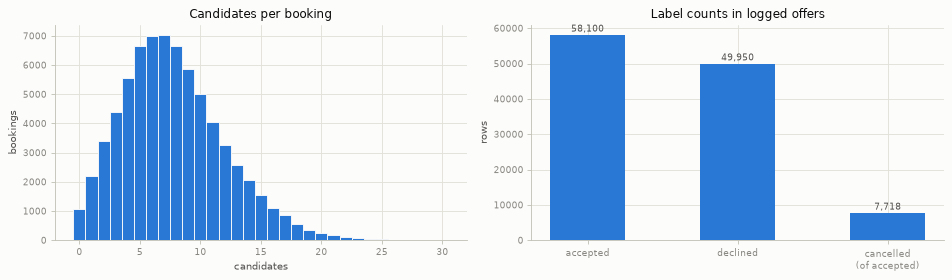

In [7]:
per_booking = cand.groupby("booking_id").size().reindex(train_bookings["booking_id"], fill_value=0)
label_counts = pd.Series({
    "accepted": int(offers["accepted"].sum()),
    "declined": int((~offers["accepted"]).sum()),
    "cancelled\n(of accepted)": int(accepted_offers["cancelled"].sum()),
})

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(per_booking, bins=np.arange(0, per_booking.max() + 2) - 0.5, color=SERIES[0], edgecolor=SURFACE, linewidth=0.8)
axes[0].set(title="Candidates per booking", xlabel="candidates", ylabel="bookings")
axes[1].bar(label_counts.index, label_counts.to_numpy(), width=0.5, color=SERIES[0])
axes[1].set(title="Label counts in logged offers", ylabel="rows")
for x, value in enumerate(label_counts.to_numpy()):
    axes[1].annotate(f"{value:,}", (x, value), textcoords="offset points", xytext=(0, 3), ha="center", fontsize=8, color=INK_2)
plt.tight_layout()
plt.show()

## 4. Phân phối

ETA và distance được vẽ cho **mọi candidate** và cho **tài xế được offer** — khoảng cách giữa hai đường chính là selection bias của log.

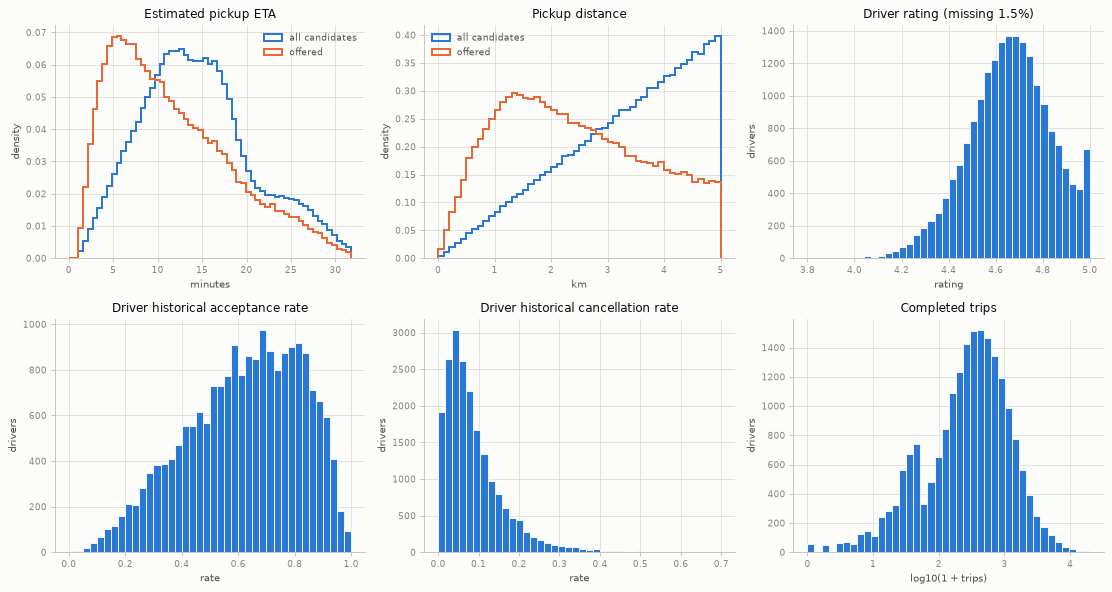

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))

ax = axes[0, 0]
bins = np.linspace(0, cand["estimated_eta_min"].quantile(0.995), 60)
ax.hist(cand["estimated_eta_min"], bins=bins, density=True, histtype="step", linewidth=1.8, color=SERIES[0], label="all candidates")
ax.hist(offers["estimated_eta_min"], bins=bins, density=True, histtype="step", linewidth=1.8, color=SERIES[1], label="offered")
ax.set(title="Estimated pickup ETA", xlabel="minutes", ylabel="density")
ax.legend()

ax = axes[0, 1]
bins = np.linspace(0, 5, 51)
ax.hist(cand["distance_km"], bins=bins, density=True, histtype="step", linewidth=1.8, color=SERIES[0], label="all candidates")
ax.hist(offers["distance_km"], bins=bins, density=True, histtype="step", linewidth=1.8, color=SERIES[1], label="offered")
ax.set(title="Pickup distance", xlabel="km", ylabel="density")
ax.legend()

bar_style = {"color": SERIES[0], "edgecolor": SURFACE, "linewidth": 0.8}
ax = axes[0, 2]
ax.hist(drivers["rating"].dropna(), bins=40, **bar_style)
ax.set(title=f"Driver rating (missing {drivers['rating'].isna().mean():.1%})", xlabel="rating", ylabel="drivers")

ax = axes[1, 0]
ax.hist(drivers["acceptance_rate"], bins=40, **bar_style)
ax.set(title="Driver historical acceptance rate", xlabel="rate", ylabel="drivers")

ax = axes[1, 1]
ax.hist(drivers["cancellation_rate"], bins=40, **bar_style)
ax.set(title="Driver historical cancellation rate", xlabel="rate", ylabel="drivers")

ax = axes[1, 2]
ax.hist(np.log10(drivers["completed_trips"] + 1), bins=40, **bar_style)
ax.set(title="Completed trips", xlabel="log10(1 + trips)", ylabel="drivers")

plt.tight_layout()
plt.show()

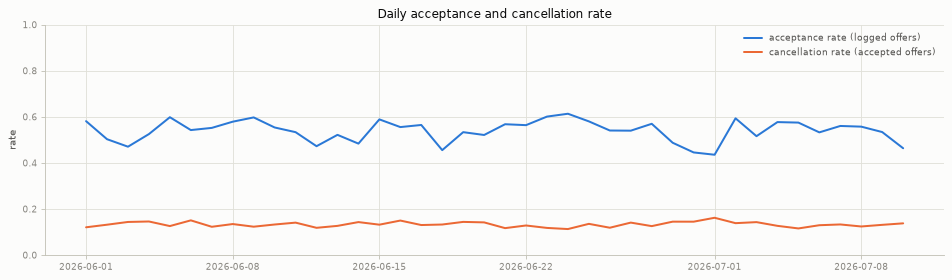

,acceptance_rate,cancellation_rate
mean,0.540,0.133
std,0.046,0.011
min,0.435,0.113
max,0.613,0.162


In [9]:
daily = pd.DataFrame({
    "acceptance_rate": offers.groupby(offers["request_time"].dt.floor("D"))["accepted"].mean(),
    "cancellation_rate": accepted_offers.groupby(accepted_offers["request_time"].dt.floor("D"))["cancelled"].mean(),
})
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.plot(daily.index, daily["acceptance_rate"], color=SERIES[0], label="acceptance rate (logged offers)")
ax.plot(daily.index, daily["cancellation_rate"], color=SERIES[1], label="cancellation rate (accepted offers)")
ax.set(title="Daily acceptance and cancellation rate", ylabel="rate", ylim=(0, 1))
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()
daily.describe().loc[["mean", "std", "min", "max"]]

In [10]:
numeric_columns = ["estimated_eta_min", "distance_km", "idle_time_min", "trip_km", "rating",
                   "acceptance_rate", "cancellation_rate", "completed_trips"]
offers[numeric_columns].describe(percentiles=[0.05, 0.5, 0.95]).T

,count,mean,std,min,5%,50%,95%,max
estimated_eta_min,108050.0,11.674,6.807,1.010,3.020,10.310,25.090,38.580
distance_km,108050.0,2.407,1.268,0.004,0.556,2.264,4.637,5.000
idle_time_min,108050.0,8.643,10.042,0.000,0.400,5.400,27.800,162.800
trip_km,108050.0,8.406,4.370,1.001,1.939,8.122,16.051,25.658
rating,106450.0,4.653,0.175,3.800,4.350,4.660,4.940,5.000
acceptance_rate,108050.0,0.620,0.203,0.000,0.256,0.641,0.910,1.000
cancellation_rate,108050.0,0.087,0.074,0.000,0.000,0.068,0.230,0.698
completed_trips,108050.0,636.047,1073.901,0.000,16.000,320.000,2248.000,20000.000


## 5. Outliers

Quy tắc IQR: giá trị ngoài `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`. Mỗi biến được đo ở đúng cấp của nó
(candidate, booking hoặc driver) để tài xế xuất hiện nhiều lần không bị đếm lặp.

In [11]:
def iqr_summary(values):
    q1, q3 = values.quantile([0.25, 0.75])
    low, high = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
    return pd.Series({
        "q1": q1, "q3": q3, "lower_fence": low, "upper_fence": high, "min": values.min(), "max": values.max(),
        "pct_below": 100 * (values < low).mean(), "pct_above": 100 * (values > high).mean(),
    })


outlier_sources = {
    "estimated_eta_min (candidate)": cand["estimated_eta_min"],
    "distance_km (candidate)": cand["distance_km"],
    "idle_time_min (candidate)": cand["idle_time_min"],
    "trip_km (booking)": train_bookings["trip_km"],
    "completed_trips (driver)": drivers["completed_trips"].astype(float),
    "cancellation_rate (driver)": drivers["cancellation_rate"],
    "acceptance_rate (driver)": drivers["acceptance_rate"],
    "rating (driver)": drivers["rating"].dropna(),
}
pd.DataFrame({name: iqr_summary(values) for name, values in outlier_sources.items()}).T.round(2)

,q1,q3,lower_fence,upper_fence,min,max,pct_below,pct_above
estimated_eta_min (candidate),9.94,18.23,-2.50,30.67,1.01,41.25,0.00,0.95
distance_km (candidate),2.50,4.33,-0.24,7.07,0.00,5.00,0.00,0.00
idle_time_min (candidate),2.40,12.60,-12.90,27.90,0.00,180.00,0.00,6.00
trip_km (booking),5.19,11.69,-4.55,21.43,1.00,25.66,0.00,0.25
completed_trips (driver),111.75,742.00,-833.62,1687.38,0.00,20000.00,0.00,8.18
cancellation_rate (driver),0.04,0.12,-0.08,0.23,0.00,0.70,0.00,4.61
acceptance_rate (driver),0.48,0.78,0.02,1.24,0.00,1.00,0.01,0.00
rating (driver),4.54,4.77,4.20,5.11,3.80,5.00,0.73,0.00


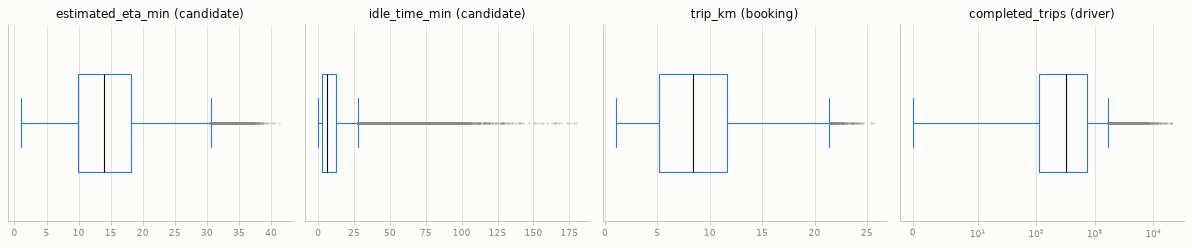

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
box_style = {
    "orientation": "horizontal", "widths": 0.5, "whis": 1.5,
    "boxprops": {"color": SERIES[0]}, "whiskerprops": {"color": SERIES[0]}, "capprops": {"color": SERIES[0]},
    "medianprops": {"color": INK}, "flierprops": {"marker": "o", "markersize": 2, "markerfacecolor": MUTED,
                                                  "markeredgecolor": "none", "alpha": 0.3},
}
for ax, (name, values) in zip(axes, [
    ("estimated_eta_min (candidate)", cand["estimated_eta_min"]),
    ("idle_time_min (candidate)", cand["idle_time_min"]),
    ("trip_km (booking)", train_bookings["trip_km"]),
    ("completed_trips (driver)", drivers["completed_trips"]),
]):
    ax.boxplot(values.dropna(), **box_style)
    ax.set(title=name, yticks=[])
axes[3].set_xscale("symlog", linthresh=10)
plt.tight_layout()
plt.show()

## 6. Tỷ lệ nhận chuyến theo từng feature

Mỗi điểm là một bin theo quantile (~cùng số offer), trục x là median của bin, thanh lỗi là khoảng tin cậy 95%.
Đường xám ngang là acceptance rate chung. Đây là quan hệ **một biến** — chưa loại trừ ảnh hưởng của biến khác.

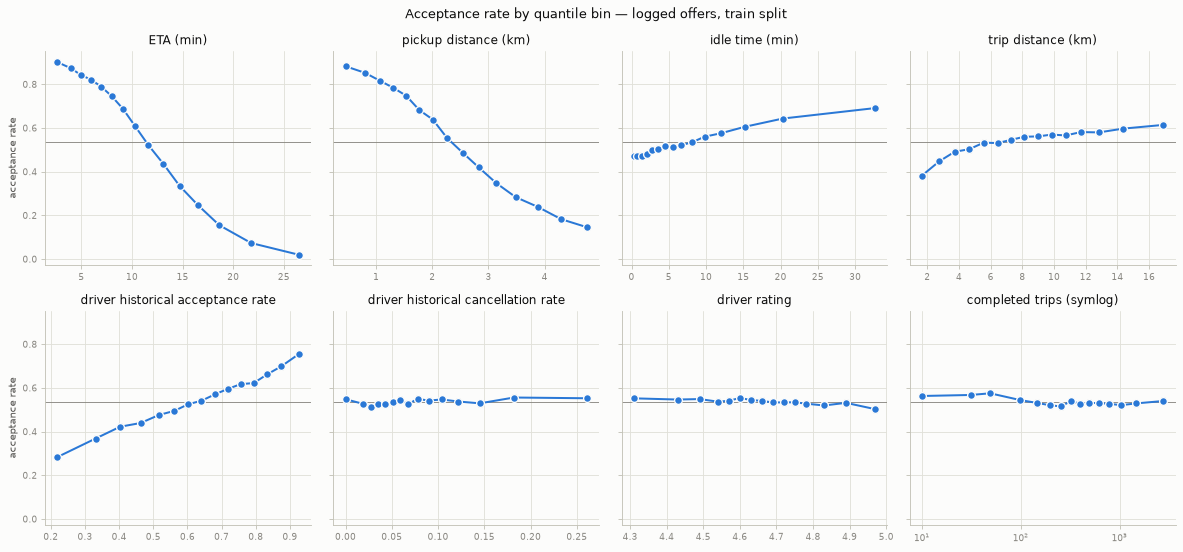

In [13]:
def rate_by_quantile_bins(df, column, n_bins=15):
    edges = np.unique(df[column].quantile(np.linspace(0, 1, n_bins + 1)))
    binned = pd.cut(df[column], bins=edges, include_lowest=True)
    grouped = df.groupby(binned, observed=True)
    table = grouped["accepted"].agg(rate="mean", n="size")
    table["x"] = grouped[column].median()
    table["ci95"] = 1.96 * np.sqrt(table["rate"] * (1 - table["rate"]) / table["n"])
    return table


numeric_features = [
    ("estimated_eta_min", "ETA (min)"), ("distance_km", "pickup distance (km)"),
    ("idle_time_min", "idle time (min)"), ("trip_km", "trip distance (km)"),
    ("acceptance_rate", "driver historical acceptance rate"), ("cancellation_rate", "driver historical cancellation rate"),
    ("rating", "driver rating"), ("completed_trips", "completed trips (symlog)"),
]
overall_rate = offers["accepted"].mean()
fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharey=True)
for ax, (column, label) in zip(axes.flat, numeric_features):
    table = rate_by_quantile_bins(offers.dropna(subset=[column]), column)
    ax.axhline(overall_rate, color=MUTED, linewidth=0.8)
    ax.errorbar(table["x"], table["rate"], yerr=table["ci95"], color=SERIES[0], ecolor=INK_2, elinewidth=0.8,
                marker="o", capsize=2)
    ax.set(title=label)
    if column == "completed_trips":
        ax.set_xscale("symlog", linthresh=10)
for ax in axes[:, 0]:
    ax.set_ylabel("acceptance rate")
fig.suptitle("Acceptance rate by quantile bin — logged offers, train split", color=INK)
plt.tight_layout()
plt.show()

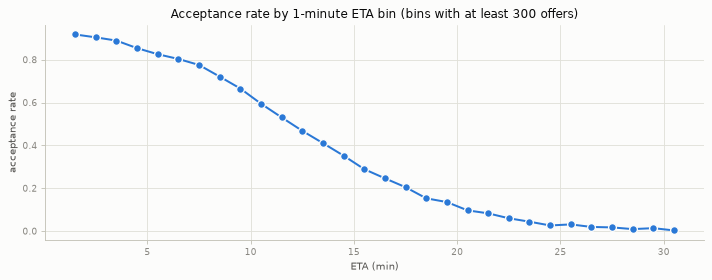

In [14]:
eta_table = offers.groupby(pd.cut(offers["estimated_eta_min"], np.arange(0, 41, 1.0)), observed=True)["accepted"].agg(
    rate="mean", n="size"
)
eta_table = eta_table[eta_table["n"] >= 300]
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot([interval.mid for interval in eta_table.index], eta_table["rate"], color=SERIES[0], marker="o")
ax.set(title="Acceptance rate by 1-minute ETA bin (bins with at least 300 offers)", xlabel="ETA (min)",
       ylabel="acceptance rate")
plt.tight_layout()
plt.show()

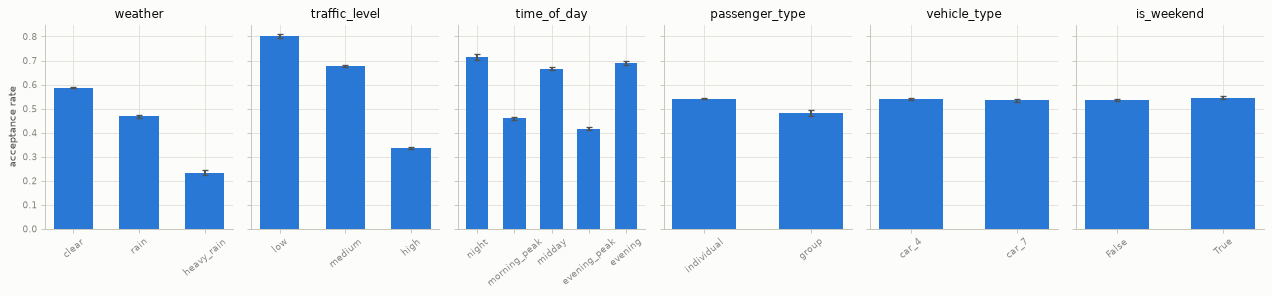

rate       n   ci95
weather        clear         0.588   75422  0.004
               rain          0.468   26287  0.006
               heavy_rain    0.233    6341  0.010
traffic_level  low           0.802   12066  0.007
               medium        0.676   47660  0.004
               high          0.336   48324  0.004
time_of_day    night         0.716    5052  0.012
               morning_peak  0.459   27889  0.006
               midday        0.666   27858  0.006
               evening_peak  0.417   34692  0.005
               evening       0.689   12559  0.008
passenger_type individual    0.541  101398  0.003
               group         0.482    6652  0.012
vehicle_type   car_4         0.539   76101  0.004
               car_7         0.534   31949  0.005
is_weekend     False         0.536   83926  0.003
               True          0.545   24124  0.006

In [15]:
categorical_features = ["weather", "traffic_level", "time_of_day", "passenger_type", "vehicle_type", "is_weekend"]
fig, axes = plt.subplots(1, len(categorical_features), figsize=(16, 3.8), sharey=True)
category_tables = {}
for ax, column in zip(axes, categorical_features):
    table = offers.groupby(column, observed=True)["accepted"].agg(rate="mean", n="size")
    table["ci95"] = 1.96 * np.sqrt(table["rate"] * (1 - table["rate"]) / table["n"])
    category_tables[column] = table
    ax.bar(table.index.astype(str), table["rate"], width=0.6, color=SERIES[0], yerr=table["ci95"], ecolor=INK_2, capsize=3)
    ax.set(title=column)
    ax.tick_params(axis="x", rotation=40)
axes[0].set_ylabel("acceptance rate")
plt.tight_layout()
plt.show()
pd.concat({column: table.set_axis(table.index.astype(str)) for column, table in category_tables.items()})

## 7. Confounding & selection bias

**Confounding:** traffic cao làm ETA dài hơn. Acceptance thấp ở traffic `high` là do traffic, do ETA, hay cả hai?
So sánh trong cùng một khoảng ETA sẽ tách được một phần.

,offers,acceptance_rate,median_eta_min
traffic_level,,,
low,12066,0.802,5.69
medium,47660,0.676,8.30
high,48324,0.336,15.17


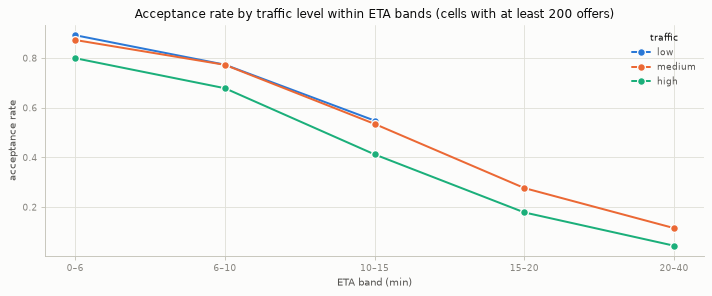

traffic_level,low,medium,high
estimated_eta_min,,,
"(0, 6]",0.892,0.873,0.800
"(6, 10]",0.774,0.773,0.679
"(10, 15]",0.548,0.535,0.412
"(15, 20]",NaN,0.277,0.179
"(20, 40]",NaN,0.116,0.045


In [16]:
by_traffic = offers.groupby("traffic_level", observed=True).agg(
    offers=("accepted", "size"), acceptance_rate=("accepted", "mean"), median_eta_min=("estimated_eta_min", "median")
)
display(by_traffic)

eta_band = pd.cut(offers["estimated_eta_min"], [0, 6, 10, 15, 20, 40])
stratified = offers.groupby([eta_band, "traffic_level"], observed=True)["accepted"].agg(rate="mean", n="size").reset_index()
stratified = stratified[stratified["n"] >= 200]
bands = eta_band.cat.categories

fig, ax = plt.subplots(figsize=(9, 3.8))
for color, (level, group) in zip(SERIES, stratified.groupby("traffic_level", observed=True)):
    ax.plot(group["estimated_eta_min"].cat.codes, group["rate"], color=color, marker="o", label=str(level))
ax.set_xticks(range(len(bands)), [f"{band.left:g}–{band.right:g}" for band in bands])
ax.set(title="Acceptance rate by traffic level within ETA bands (cells with at least 200 offers)",
       xlabel="ETA band (min)", ylabel="acceptance rate")
ax.legend(title="traffic", title_fontsize=8)
plt.tight_layout()
plt.show()
stratified.pivot(index="estimated_eta_min", columns="traffic_level", values="rate")

Cùng cách so sánh cho các biến ngữ cảnh khác: acceptance rate chung, median ETA, số candidate, và acceptance rate **trong từng khoảng ETA**.

In [17]:
def within_eta_bands(column):
    overall = offers.groupby(column, observed=True).agg(
        offers=("accepted", "size"), acceptance_rate=("accepted", "mean"),
        median_eta_min=("estimated_eta_min", "median"), median_candidates=("n_candidates_in_booking", "median"),
    )
    banded = offers.groupby([eta_band, column], observed=True)["accepted"].agg(rate="mean", n="size").reset_index()
    banded = banded[banded["n"] >= 200].pivot(index="estimated_eta_min", columns=column, values="rate")
    return overall, banded


for column in ["passenger_type", "time_of_day", "weather"]:
    overall, banded = within_eta_bands(column)
    print(f"--- {column} ---")
    display(overall)
    display(banded)

--- passenger_type ---


,offers,acceptance_rate,median_eta_min,median_candidates
passenger_type,,,,
individual,101398,0.541,10.13,7.0
group,6652,0.482,13.20,2.0


passenger_type,individual,group
estimated_eta_min,,
"(0, 6]",0.864,0.879
"(6, 10]",0.742,0.805
"(10, 15]",0.474,0.550
"(15, 20]",0.210,0.264
"(20, 40]",0.047,0.049


--- time_of_day ---


,offers,acceptance_rate,median_eta_min,median_candidates
time_of_day,,,,
night,5052,0.716,6.995,6.0
morning_peak,27889,0.459,12.350,6.0
midday,27858,0.666,7.680,10.0
evening_peak,34692,0.417,13.400,6.0
evening,12559,0.689,7.600,8.0


time_of_day,night,morning_peak,midday,evening_peak,evening
estimated_eta_min,,,,,
"(0, 6]",0.887,0.857,0.874,0.834,0.873
"(6, 10]",0.742,0.733,0.766,0.717,0.773
"(10, 15]",0.445,0.462,0.512,0.456,0.546
"(15, 20]",NaN,0.199,0.247,0.207,0.261
"(20, 40]",NaN,0.046,0.040,0.047,0.060


--- weather ---


,offers,acceptance_rate,median_eta_min,median_candidates
weather,,,,
clear,75422,0.588,9.52,8.0
rain,26287,0.468,11.67,6.0
heavy_rain,6341,0.233,15.15,4.0


weather,clear,rain,heavy_rain
estimated_eta_min,,,
"(0, 6]",0.875,0.838,0.723
"(6, 10]",0.762,0.723,0.554
"(10, 15]",0.514,0.445,0.247
"(15, 20]",0.242,0.198,0.067
"(20, 40]",0.057,0.043,0.010


**Selection bias:** với booking `nearest`, offer đầu tiên luôn là tài xế gần nhất; với booking `explore`, offer đầu tiên là một candidate
ngẫu nhiên. Chỉ dùng **offer đầu tiên** của booking `explore` để có một mẫu không bị điều kiện hoá bởi các lượt từ chối trước đó.

,bookings,acceptance_rate,median_distance_km,median_eta_min,median_candidates
logging_policy,,,,,
nearest,56428,0.702,1.532,6.96,7.0
explore,14371,0.415,3.539,14.20,7.0


,offers,acceptance_rate,median_eta_min,median_candidates
"explore, first offer was the nearest",2780,0.606,8.65,4.0
"nearest policy, first offer",56428,0.702,6.96,7.0


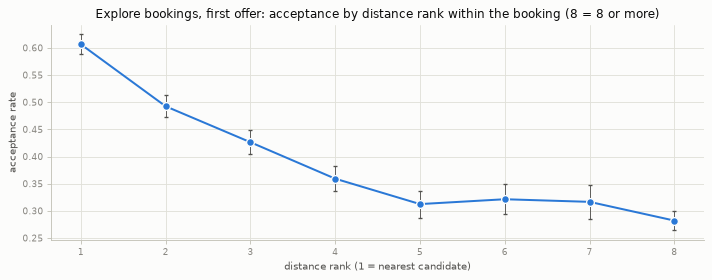

,rate,n,ci95
distance_rank_in_booking,,,
1,0.606,2780,0.018
2,0.492,2299,0.020
3,0.426,1980,0.022
4,0.359,1626,0.023
5,0.312,1338,0.025
6,0.321,1111,0.027
7,0.317,872,0.031
8,0.282,2365,0.018


In [18]:
first_offers = offers[offers["offer_rank"] == 1]
display(first_offers.groupby("logging_policy", observed=True).agg(
    bookings=("booking_id", "size"), acceptance_rate=("accepted", "mean"),
    median_distance_km=("distance_km", "median"), median_eta_min=("estimated_eta_min", "median"),
    median_candidates=("n_candidates_in_booking", "median"),
))

explore_first = first_offers[first_offers["logging_policy"] == "explore"]
# The nearest driver is accepted less often under explore than under the nearest policy: compare the two groups.
display(pd.concat({
    "nearest policy, first offer": first_offers[first_offers["logging_policy"] == "nearest"],
    "explore, first offer was the nearest": explore_first[explore_first["distance_rank_in_booking"] == 1],
}).groupby(level=0).agg(
    offers=("accepted", "size"), acceptance_rate=("accepted", "mean"), median_eta_min=("estimated_eta_min", "median"),
    median_candidates=("n_candidates_in_booking", "median"),
))
by_rank = explore_first.groupby(explore_first["distance_rank_in_booking"].clip(upper=8))["accepted"].agg(rate="mean", n="size")
by_rank["ci95"] = 1.96 * np.sqrt(by_rank["rate"] * (1 - by_rank["rate"]) / by_rank["n"])

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.errorbar(by_rank.index, by_rank["rate"], yerr=by_rank["ci95"], color=SERIES[0], ecolor=INK_2, elinewidth=0.8,
            marker="o", capsize=2)
ax.set(title="Explore bookings, first offer: acceptance by distance rank within the booking (8 = 8 or more)",
       xlabel="distance rank (1 = nearest candidate)", ylabel="acceptance rate")
plt.tight_layout()
plt.show()
by_rank

## 8. Tương quan (Spearman)

Spearman đo quan hệ đơn điệu (không cần tuyến tính) và ít nhạy với outlier hơn Pearson.

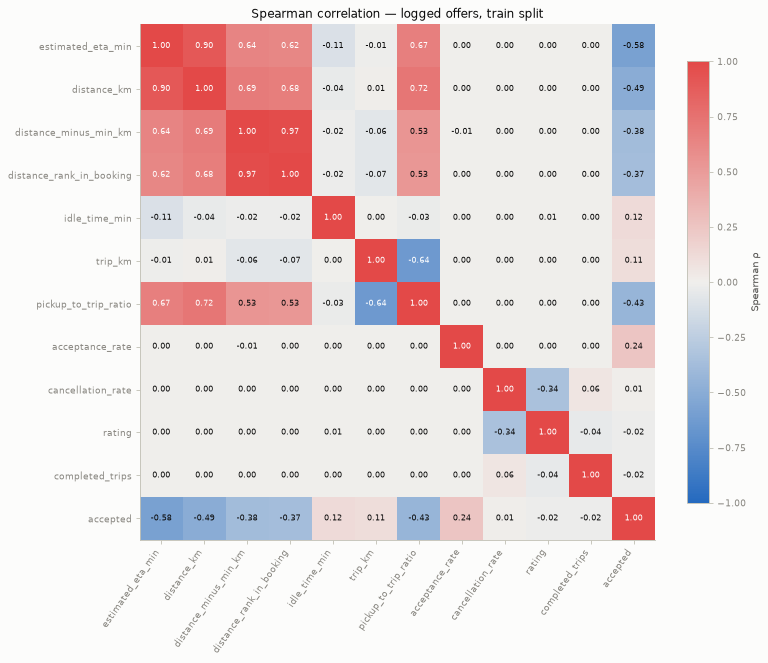

estimated_eta_min          -0.585
distance_km                -0.494
pickup_to_trip_ratio       -0.432
distance_minus_min_km      -0.376
distance_rank_in_booking   -0.369
completed_trips            -0.022
rating                     -0.022
cancellation_rate           0.012
trip_km                     0.108
idle_time_min               0.119
acceptance_rate             0.245
Name: accepted, dtype: float64

In [19]:
correlation_columns = [
    "estimated_eta_min", "distance_km", "distance_minus_min_km", "distance_rank_in_booking", "idle_time_min", "trip_km",
    "pickup_to_trip_ratio", "acceptance_rate", "cancellation_rate", "rating", "completed_trips", "accepted",
]
corr = offers[correlation_columns].astype(float).corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8.5))
image = ax.imshow(corr, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation_columns)), correlation_columns, rotation=55, ha="right")
ax.set_yticks(range(len(correlation_columns)), correlation_columns)
for i in range(len(correlation_columns)):
    for j in range(len(correlation_columns)):
        value = corr.iloc[i, j]
        label = f"{value:.2f}".replace("-0.00", "0.00")
        ax.text(j, i, label, ha="center", va="center", fontsize=7, color="white" if abs(value) > 0.6 else INK)
ax.grid(False)
fig.colorbar(image, ax=ax, shrink=0.8, label="Spearman ρ")
ax.set_title("Spearman correlation — logged offers, train split")
plt.tight_layout()
plt.show()
corr["accepted"].drop("accepted").sort_values()

## 9. Feature importance sơ bộ (một biến)

Hai thước đo bổ trợ nhau, tính trên 60.000 logged offers lấy mẫu ngẫu nhiên từ tập train:

- **Univariate ROC-AUC** — nếu chỉ dùng một feature để xếp hạng thì phân biệt nhận/từ chối tốt đến đâu. `signal_auc = max(AUC, 1 − AUC)`
  bỏ qua chiều. Chỉ bắt được quan hệ đơn điệu; không áp dụng cho biến nominal (`time_of_day`).
- **Mutual information** — lượng thông tin feature mang về nhãn, bắt được cả quan hệ không đơn điệu.

In [20]:
numeric = ["estimated_eta_min", "distance_km", "distance_minus_min_km", "distance_rank_in_booking", "idle_time_min",
           "trip_km", "pickup_to_trip_ratio", "acceptance_rate", "cancellation_rate", "rating", "completed_trips", "hour"]
ordered_or_binary = ["weather", "traffic_level", "passenger_type", "vehicle_type", "is_weekend", "has_rating"]
nominal = ["time_of_day"]
columns = numeric + ordered_or_binary + nominal


def encode(series):
    if isinstance(series.dtype, pd.CategoricalDtype):
        return series.cat.codes.astype(float)
    return series.astype(float)


sample = offers.sample(n=min(60_000, len(offers)), random_state=SEED)
X = pd.DataFrame({column: encode(sample[column]) for column in columns})
X["rating"] = X["rating"].fillna(X["rating"].median())  # MI cannot take NaN; missingness is its own feature: has_rating
y = sample["accepted"].to_numpy()

mutual_info = mutual_info_classif(X, y, discrete_features=np.array([c not in numeric for c in columns]), random_state=SEED)
auc = [roc_auc_score(y, X[column]) if column not in nominal else np.nan for column in columns]
importance = pd.DataFrame({"mutual_info": mutual_info, "univariate_auc": auc}, index=columns)
importance["signal_auc"] = np.maximum(importance["univariate_auc"], 1 - importance["univariate_auc"])
importance["direction"] = np.select(
    [importance["univariate_auc"] > 0.5, importance["univariate_auc"] < 0.5],
    ["higher → more accepts", "higher → fewer accepts"], default="n/a (nominal)",
)
importance = importance.sort_values("mutual_info", ascending=False)
importance.round(4)

,mutual_info,univariate_auc,signal_auc,direction
estimated_eta_min,2.010e-01,0.163,0.837,higher → fewer accepts
distance_km,1.323e-01,0.215,0.785,higher → fewer accepts
pickup_to_trip_ratio,1.017e-01,0.251,0.749,higher → fewer accepts
distance_rank_in_booking,7.100e-02,0.310,0.690,higher → fewer accepts
distance_minus_min_km,7.030e-02,0.306,0.694,higher → fewer accepts
traffic_level,7.020e-02,0.307,0.693,higher → fewer accepts
trip_km,4.640e-02,0.560,0.560,higher → more accepts
acceptance_rate,3.240e-02,0.642,0.642,higher → more accepts
hour,2.990e-02,0.495,0.505,higher → fewer accepts
time_of_day,2.970e-02,NaN,NaN,n/a (nominal)


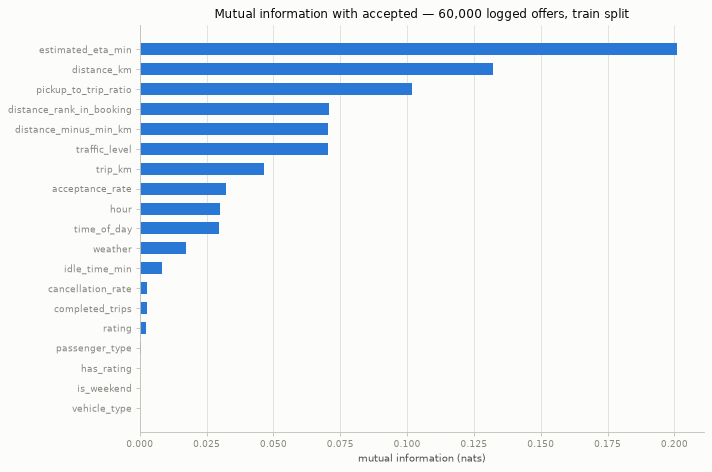

In [21]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importance.index[::-1], importance["mutual_info"][::-1], height=0.6, color=SERIES[0])
ax.set(title="Mutual information with accepted — 60,000 logged offers, train split", xlabel="mutual information (nats)")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

**Giới hạn của feature importance một biến:**

- Feature tương quan mạnh với nhau (ví dụ `distance_km` và `estimated_eta_min`) **chia nhau cùng một tín hiệu** — cả hai cao không có nghĩa
  model cần cả hai.
- Feature yếu khi đứng một mình vẫn có thể quan trọng khi **tương tác** với feature khác.
- Tất cả tính trên logged offers → chịu selection bias của logging policy.
- Importance dựa trên model (permutation, SHAP) và ablation được làm ở Phase 5–6 trên đúng split.

## 10. Findings

Số liệu từ tập train (71,863 booking · 558,334 candidate · 108,050 logged offers). Bảng chi tiết và hệ quả cho Phase 4–5:
`docs/research.md` §9.

1. **Chất lượng dữ liệu tốt.** Không trùng khoá. Missing của `offer_rank` / `accepted` / `cancelled` đúng là structural.
   `rating` thiếu ở 292 tài xế (1.46%), tất cả có dưới 5 chuyến → missing có thông tin.
2. **Nhãn cân bằng.** Acceptance 0.538 trên logged offers → không cần resampling. Cancellation 0.133 trên chuyến đã nhận (lệch,
   nhưng không phải target của MVP). Chỉ 19.4% dòng candidate có nhãn.
3. **ETA / distance là tín hiệu một biến mạnh nhất** (univariate AUC 0.837 / 0.785), quan hệ dạng chữ S, dốc nhất khoảng 8–16 phút.
   ETA và distance tương quan ρ = 0.90.
4. **Tín hiệu từ tài xế bổ sung chứ không trùng lặp.** `acceptance_rate` lịch sử tăng đơn điệu (≈ 0.28 → 0.76 theo bin) và gần như không
   tương quan với feature không gian. `rating`, `cancellation_rate`, `completed_trips` gần như không liên quan tới việc *nhận* chuyến.
5. **Confounding.** Chênh lệch theo traffic và khung giờ phần lớn đi qua ETA: trong cùng khoảng ETA, traffic `low` ≈ `medium`.
   `heavy_rain` vẫn thấp hơn rõ và khoảng cách lớn dần khi ETA tăng (dấu hiệu tương tác).
   **Simpson's paradox:** booking `group` có acceptance chung thấp hơn (0.482 vs 0.541) nhưng *cao hơn* ở mọi khoảng ETA — vì group chỉ có
   median 2 candidate phù hợp nên tài xế ở xa hơn (median ETA 13.2 vs 10.1 phút).
6. **Selection bias.** Offer đầu tiên của policy `nearest` được nhận 0.702 (median ETA 6.96 phút) so với `explore` 0.415 (14.20 phút).
   Ngay cả "explore trúng tài xế gần nhất" cũng chỉ 0.606, vì trường hợp đó rơi vào booking ít candidate hơn (median 4 vs 7).
   `offer_rank` và `logging_policy` gắn chặt với nhãn nhưng là sản phẩm của log → **không được làm feature**.
7. **Outlier là giá trị hợp lệ của phân phối lệch** (idle time 6.0% vượt fence, completed trips 8.2%) → giữ lại; log-transform cho
   Logistic Regression.
8. **Importance một biến có giới hạn:** `passenger_type` có mutual information ≈ 0 nhưng có tác động rõ khi so trong cùng khoảng ETA.
   Việc chọn feature cuối cùng dành cho ablation ở Phase 5–6.